# Student Participation Prediction Model

**Problem Statement:**
Develop a machine learning model to predict student participation in
opportunities, and estimate the probability that students will
participate in upcoming opportunities.

**Algorithm used:** Random Forest Classifier

This notebook is organized into clear stages:
1. Load data
2. Clean data
3. Define target (Y) and features (X)
4. Train/test split
5. Build and train the Random Forest model
6. Evaluate performance
7. Inspect feature importance
8. Use the model to estimate participation **probability** for new/upcoming applicants


## 1. Imports

In [1]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score
)
import joblib


## 2. Load the raw data

Update `RAW_PATH` to point to your `RIT.csv` file.

In [2]:
RAW_PATH = "RIT.csv"   # <-- change this path if needed

df = pd.read_csv(RAW_PATH)
print("Raw shape:", df.shape)
df.head()


Raw shape: (8041, 21)


,Learner SignUp DateTime,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity End Date,First Name,Date of Birth,Gender,Country,Institution Name,...,Entry created at,Status Description,Status Code,Apply Date,Opportunity Start Date,Age,Days_SignUp_to_Apply,Days_Apply_to_Start,Missing_Opportunity_Start,Participated
0,2023-06-14 12:30:35,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Faria,2001-01-12,Female,Pakistan,Nwihs,...,2024-03-11 12:01:41,Started,1080,2023-06-14 12:36:09,2022-11-03 18:30:39,22.417522,0.0,-223.0,0,1
1,2023-05-01 05:29:16,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Poojitha,2000-08-16,Female,India,SAINT LOUIS,...,2024-03-11 12:01:41,Started,1080,2023-05-01 06:08:21,2022-11-03 18:30:39,22.704997,0.0,-179.0,0,1
2,2023-08-29 05:20:03,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Amrutha Varshini,1999-11-01,Female,United States,Saint Louis University,...,2024-03-11 12:01:41,Team Allocated,1070,2023-10-09 22:02:42,2022-11-03 18:30:39,23.824778,41.0,-341.0,0,1
3,2023-01-06 15:26:36,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Vinay Varshith,2000-04-19,Male,United States,Saint Louis University,...,2024-03-11 12:01:41,Started,1080,2023-01-06 15:40:10,2022-11-03 18:30:39,22.715948,0.0,-64.0,0,1
4,2024-03-02 19:16:07,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Mor,1996-05-12,Male,India,Saint Louis University,...,2024-03-11 12:01:41,Waitlisted,1040,2024-03-02 20:30:35,NaN,27.805613,0.0,-12.0,1,0


## 3. Data Cleaning

The raw data has a few issues that need fixing before modeling:

1. **Corrupted timestamps** — a subset of `Apply Date` values have stray
   digits injected into the hour field (e.g. `05/11/2023 1085640:21:29`).
   We repair these by keeping only the last 2 digits of the hour.
2. **Date columns stored as text** — all date/time columns are parsed
   into proper `datetime` objects.
3. **Duplicate rows** are removed.
4. **Inconsistent text casing** in Country / Major / Institution is
   standardized.
5. **Missing values** in Institution / Major are filled with `"Unknown"`
   rather than dropped, since we don't want to lose rows over a
   non-critical field.
6. **Age** is derived from Date of Birth vs. Signup date. Biologically
   implausible ages (<10 or >80) are treated as missing and imputed
   with the median.
7. **Timing features** are derived:
   - `Days_SignUp_to_Apply`: how long after signing up the student applied
   - `Days_Apply_to_Start`: how long between applying and the opportunity's start
   - `Missing_Opportunity_Start`: flag for opportunities with no start date on record


In [3]:
def fix_apply_date(x):
    """Repair corrupted 'Apply Date' strings that have extra digits
    injected into the hour portion of the timestamp."""
    m = re.match(r"(\d{2}/\d{2}/\d{4}) (\d+):(\d{2}):(\d{2})", str(x))
    if m:
        date_part, hh, mm, ss = m.groups()
        hh = hh[-2:]  # keep only the last 2 digits as the real hour
        return f"{date_part} {hh}:{mm}:{ss}"
    return x

df["Apply Date"] = df["Apply Date"].apply(fix_apply_date)

# Parse all date/time columns
date_cols = [
    "Learner SignUp DateTime", "Opportunity End Date", "Date of Birth",
    "Entry created at", "Apply Date", "Opportunity Start Date",
]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")

# Drop exact duplicate rows
df = df.drop_duplicates()

# Standardize text fields
df["Gender"] = df["Gender"].str.strip()
df["Country"] = df["Country"].str.strip().str.title()
df["Institution Name"] = df["Institution Name"].str.strip()
df["Current/Intended Major"] = df["Current/Intended Major"].str.strip().str.title()
df["Opportunity Category"] = df["Opportunity Category"].str.strip()
df["Status Description"] = df["Status Description"].str.strip()

# Fill missing categorical text
for c in ["Institution Name", "Current/Intended Major"]:
    df[c] = df[c].fillna("Unknown")

# Derive Age at signup
df["Age"] = (df["Learner SignUp DateTime"] - df["Date of Birth"]).dt.days / 365.25
df.loc[(df["Age"] < 10) | (df["Age"] > 80), "Age"] = np.nan
df["Age"] = df["Age"].fillna(df["Age"].median())

# Derive timing features
df["Days_SignUp_to_Apply"] = (df["Apply Date"] - df["Learner SignUp DateTime"]).dt.days
df["Days_SignUp_to_Apply"] = df["Days_SignUp_to_Apply"].clip(lower=0)

df["Missing_Opportunity_Start"] = df["Opportunity Start Date"].isna().astype(int)
df["Days_Apply_to_Start"] = (df["Opportunity Start Date"] - df["Apply Date"]).dt.days
df["Days_Apply_to_Start"] = df["Days_Apply_to_Start"].fillna(df["Days_Apply_to_Start"].median())

# Drop rows where we couldn't parse the core dates needed for features
df = df.dropna(subset=["Learner SignUp DateTime", "Apply Date"])

print("Cleaned shape:", df.shape)
df.head()


Cleaned shape: (8041, 21)


,Learner SignUp DateTime,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity End Date,First Name,Date of Birth,Gender,Country,Institution Name,...,Entry created at,Status Description,Status Code,Apply Date,Opportunity Start Date,Age,Days_SignUp_to_Apply,Days_Apply_to_Start,Missing_Opportunity_Start,Participated
0,2023-06-14 12:30:35,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Faria,2001-01-12,Female,Pakistan,Nwihs,...,2024-03-11 12:01:41,Started,1080,2023-06-14 12:36:09,2022-11-03 18:30:39,22.417522,0,-223.0,0,1
1,2023-05-01 05:29:16,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Poojitha,2000-08-16,Female,India,SAINT LOUIS,...,2024-03-11 12:01:41,Started,1080,2023-05-01 06:08:21,2022-11-03 18:30:39,22.704997,0,-179.0,0,1
2,2023-08-29 05:20:03,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Amrutha Varshini,1999-11-01,Female,United States,Saint Louis University,...,2024-03-11 12:01:41,Team Allocated,1070,2023-10-09 22:02:42,2022-11-03 18:30:39,23.824778,41,-341.0,0,1
3,2023-01-06 15:26:36,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Vinay Varshith,2000-04-19,Male,United States,Saint Louis University,...,2024-03-11 12:01:41,Started,1080,2023-01-06 15:40:10,2022-11-03 18:30:39,22.715948,0,-64.0,0,1
4,2024-03-02 19:16:07,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Mor,1996-05-12,Male,India,Saint Louis University,...,2024-03-11 12:01:41,Waitlisted,1040,2024-03-02 20:30:35,NaT,27.805613,0,-12.0,1,0


## 4. Define the Target (Y) and Features (X)

### Target (Y): `Participated`

The raw `Status Description` column has 8 possible values. We collapse
these into a binary outcome that matches the problem statement
("predict student **participation**"):

| Status Description | Participated? | Why |
|---|---|---|
| Started | 1 | Actively engaged |
| Team Allocated | 1 | Actively engaged |
| Dropped Out | 1 | Engaged, then left — still counts as having participated |
| Withdraw | 1 | Engaged, then left — still counts as having participated |
| Rewards Award | 1 | Completed and received a reward — clearly participated |
| Rejected | 0 | Never allowed to participate |
| Waitlisted | 0 | Never got in |
| Applied | 0 | Application never progressed |

So: `Y = 1` if the student got past the application stage into real
engagement, `Y = 0` if they never did.

### Features (X)

We only use information that is **known at, or before, the time of
application** — this avoids data leakage and keeps the model usable
for predicting **upcoming** opportunities (which is explicitly part
of the problem statement):

| Feature | Type | Why it's included |
|---|---|---|
| `Gender` | categorical | Demographic signal on participation likelihood |
| `Country` | categorical | Regional/logistical factors (timezone, access, internet) affect participation |
| `Opportunity Category` | categorical | Course vs. Internship vs. Event vs. Competition vs. Engagement — different formats have very different participation rates |
| `Current/Intended Major` | categorical | Field-of-study fit with the opportunity affects follow-through |
| `Age` | numeric | Life stage may affect availability/commitment |
| `Days_SignUp_to_Apply` | numeric | How quickly a student applied after signing up — a proxy for enthusiasm/intent |
| `Days_Apply_to_Start` | numeric | Longer gaps between applying and the opportunity starting give more time to lose interest or find a conflict |
| `Missing_Opportunity_Start` | binary flag | Opportunities without a clear start date on record behave differently (often stalled listings) |

**Columns intentionally excluded from X:** `Status Description`,
`Status Code` (these ARE the outcome, so including them would leak
the answer), and free-text identifiers like `First Name`,
`Opportunity Id`, `Opportunity Name`, `Institution Name` (too
high-cardinality / not generalizable, and not predictive on their own
without extensive feature engineering).


In [4]:
PARTICIPATED_STATUSES = {
    "Started", "Team Allocated", "Dropped Out", "Withdraw", "Rewards Award"
}
df["Participated"] = df["Status Description"].isin(PARTICIPATED_STATUSES).astype(int)

categorical_features = [
    "Gender", "Country", "Opportunity Category", "Current/Intended Major",
]
numeric_features = [
    "Age", "Days_SignUp_to_Apply", "Days_Apply_to_Start", "Missing_Opportunity_Start",
]

X = df[categorical_features + numeric_features]
y = df["Participated"]

print("Class balance (0 = Not Participated, 1 = Participated):")
print(y.value_counts(normalize=True).round(3))


Class balance (0 = Not Participated, 1 = Participated):
Participated
1    0.562
0    0.438
Name: proportion, dtype: float64


## 5. Train / Test Split

We hold out 20% of the data to evaluate the model on data it has
never seen. `stratify=y` keeps the same participation ratio in both
the train and test sets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (6432, 8)  Test size: (1609, 8)


## 6. Build the Model — Random Forest

**Why Random Forest?**
- Handles a mix of categorical and numeric features well
- Robust to outliers and doesn't require feature scaling
- Captures non-linear relationships (e.g. participation rate varying
  by opportunity category AND country together)
- Gives interpretable **feature importances**
- Outputs well-calibrated-enough probabilities via `predict_proba`,
  which is exactly what we need for "estimate the probability that
  students will participate in upcoming opportunities"

**Pipeline:**
1. `OneHotEncoder` turns categorical columns into numeric dummy
   variables (rare categories below `min_frequency=20` are grouped
   into an "infrequent" bucket to avoid overfitting on tiny groups).
2. `RandomForestClassifier` is trained on the encoded features.
3. `class_weight="balanced"` compensates for the ~56/44 class split
   so the model doesn't just favor the majority class.


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), categorical_features),
    ],
    remainder="passthrough",  # numeric features pass through unchanged
)

rf = RandomForestClassifier(
    n_estimators=300,      # number of trees in the forest
    max_depth=12,          # limits tree depth to reduce overfitting
    min_samples_leaf=5,    # each leaf needs at least 5 samples
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,              # use all CPU cores
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", rf),
])

model.fit(X_train, y_train)
print("Model trained.")


Model trained.


## 7. Evaluate the Model

We look at:
- **Accuracy** — overall % correct
- **ROC-AUC** — how well the model ranks participants above
  non-participants across all probability thresholds (more robust
  than accuracy alone)
- **Classification report** — precision/recall/F1 per class
- **Confusion matrix** — actual vs predicted breakdown


In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # probability of Participated = 1

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.3f}")
print(f"ROC-AUC:  {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Not Participated", "Participated"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.894
ROC-AUC:  0.937

                  precision    recall  f1-score   support

Not Participated       0.81      1.00      0.89       704
    Participated       1.00      0.81      0.90       905

        accuracy                           0.89      1609
       macro avg       0.90      0.91      0.89      1609
    weighted avg       0.91      0.89      0.89      1609

Confusion Matrix:
[[704   0]
 [170 735]]


## 8. Feature Importance

Shows which features the Random Forest relied on most to make its
predictions.

In [8]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = list(cat_names) + numeric_features

importances = model.named_steps["rf"].feature_importances_
feature_importance = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

feature_importance.head(15)


Missing_Opportunity_Start                     0.442839
Days_Apply_to_Start                           0.233135
Opportunity Category_Internship               0.165441
Opportunity Category_Course                   0.073878
Opportunity Category_Event                    0.021108
Age                                           0.014492
Days_SignUp_to_Apply                          0.010562
Opportunity Category_Competition              0.007665
Country_United States                         0.005411
Opportunity Category_Engagement               0.003693
Current/Intended Major_Information Systems    0.002672
Current/Intended Major_infrequent_sklearn     0.001387
Gender_Male                                   0.001236
Current/Intended Major_Other                  0.001198
Gender_Female                                 0.001197
dtype: float64

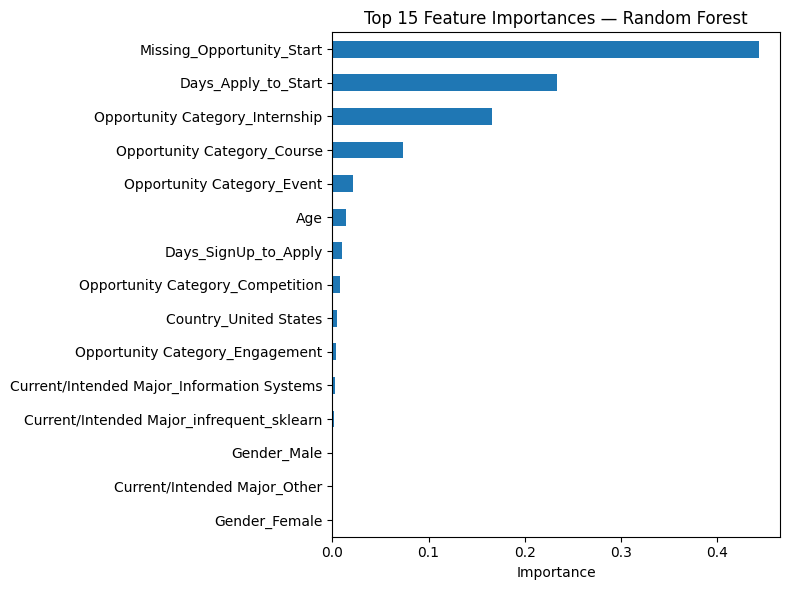

In [9]:
# Optional: visualize feature importance
import matplotlib.pyplot as plt

feature_importance.head(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 9. Estimate Participation Probability for Upcoming Opportunities

This directly answers the second half of the problem statement:
*"estimate the probability that students will participate in
upcoming opportunities."*

Given a new (or upcoming) applicant's details, the model outputs a
probability between 0 and 1 via `predict_proba`. Below is a reusable
function — plug in real applicant data to score them.


In [10]:
def predict_participation_probability(new_applicants: pd.DataFrame) -> pd.Series:
    """
    new_applicants: a DataFrame with the same feature columns as X
                     (Gender, Country, Opportunity Category,
                      Current/Intended Major, Age, Days_SignUp_to_Apply,
                      Days_Apply_to_Start, Missing_Opportunity_Start)
    Returns: a Series of participation probabilities (0-1)
    """
    probs = model.predict_proba(new_applicants)[:, 1]
    return pd.Series(probs, index=new_applicants.index, name="Participation_Probability")


# Example: score 3 hypothetical upcoming applicants
example_applicants = pd.DataFrame([
    {
        "Gender": "Female", "Country": "India", "Opportunity Category": "Internship",
        "Current/Intended Major": "Computer Science", "Age": 22,
        "Days_SignUp_to_Apply": 3, "Days_Apply_to_Start": 20, "Missing_Opportunity_Start": 0,
    },
    {
        "Gender": "Male", "Country": "United States", "Opportunity Category": "Course",
        "Current/Intended Major": "Business Administration", "Age": 25,
        "Days_SignUp_to_Apply": 30, "Days_Apply_to_Start": 5, "Missing_Opportunity_Start": 0,
    },
    {
        "Gender": "Male", "Country": "Nigeria", "Opportunity Category": "Event",
        "Current/Intended Major": "Economics", "Age": 21,
        "Days_SignUp_to_Apply": 1, "Days_Apply_to_Start": 0, "Missing_Opportunity_Start": 1,
    },
])

probabilities = predict_participation_probability(example_applicants)
result = example_applicants.copy()
result["Participation_Probability"] = probabilities
result


,Gender,Country,Opportunity Category,Current/Intended Major,Age,Days_SignUp_to_Apply,Days_Apply_to_Start,Missing_Opportunity_Start,Participation_Probability
0,Female,India,Internship,Computer Science,22,3,20,0,0.921908
1,Male,United States,Course,Business Administration,25,30,5,0,0.934167
2,Male,Nigeria,Event,Economics,21,1,0,1,0.485534


## 10. Save the Model

Persist the trained pipeline so it can be reloaded later without
retraining (e.g. in a scoring script or app).

In [11]:
joblib.dump(model, "participation_model.pkl")
print("Model saved to participation_model.pkl")

# To reload later:
# model = joblib.load("participation_model.pkl")


Model saved to participation_model.pkl
